# 05c — Compare Robustness Sweeps (Scenario A): Greedy (05a) vs QAOA (05b)

This notebook compares the outputs of:

- **05a (Greedy baseline)**: `05a_greedy_*`
- **05b (QAOA/QUBO)**: `05b_qaoa_*`

We compare methods on matched configuration keys:
- `K`, `lambda_cost`, `lambda_safety`, `noise_sigma`

Key outputs:
- A joined comparison table of aggregated sweep metrics (`05c_compare_config_metrics.csv`)
- A top-config selection overlap table (`05c_topconfig_selection_overlap.csv`)
- Two figures suitable for slides:
  - objective comparison scatter
  - overlap (Jaccard) distribution for top configs

Notes:
- “Jaccard vs baseline” in each sweep is **method-internal stability** (greedy baseline vs QAOA baseline differ).
- For cross-method alignment, we compute **Greedy vs QAOA Jaccard overlap** on the exported “top configs” selected trials.


In [1]:
# ============================================================
# Cell 1 — Setup: imports, paths, and output directories
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

# --- Project directories ---
RESULTS_DIR = Path("data/results")
FIG_DIR = Path("outputs/figures")

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Required inputs from 05a / 05b ---
PATH_05A_SWEEP = RESULTS_DIR / "05a_greedy_robustness_sweep_summary.csv"
PATH_05A_TOP_SELECTED = RESULTS_DIR / "05a_greedy_top_configs_selected_trials.csv"
PATH_05A_TOP_TABLE = RESULTS_DIR / "05a_greedy_top_config_table.csv"

PATH_05B_SWEEP = RESULTS_DIR / "05b_qaoa_robustness_sweep_summary.csv"
PATH_05B_TOP_SELECTED = RESULTS_DIR / "05b_qaoa_top_configs_selected_trials.csv"
PATH_05B_TOP_TABLE = RESULTS_DIR / "05b_qaoa_top_config_table.csv"

# --- Outputs (05c) ---
OUT_PREFIX = "05c_compare"
PATH_COMPARE_CONFIG_METRICS = RESULTS_DIR / f"{OUT_PREFIX}_config_metrics.csv"
PATH_COMPARE_TOP_OVERLAP = RESULTS_DIR / f"{OUT_PREFIX}_topconfig_selection_overlap.csv"

PATH_FIG_SCATTER = FIG_DIR / f"{OUT_PREFIX}_objective_scatter.png"
PATH_FIG_OVERLAP = FIG_DIR / f"{OUT_PREFIX}_topconfig_overlap_jaccard.png"

# --- Existence checks ---
required = [
    PATH_05A_SWEEP, PATH_05A_TOP_SELECTED, PATH_05A_TOP_TABLE,
    PATH_05B_SWEEP, PATH_05B_TOP_SELECTED, PATH_05B_TOP_TABLE
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required 05a/05b artifacts:\n" + "\n".join([str(p) for p in missing]))

print("OK: Found all required 05a/05b artifacts.")
print("Results dir:", RESULTS_DIR.resolve())
print("Figures dir:", FIG_DIR.resolve())


OK: Found all required 05a/05b artifacts.
Results dir: /home/parallels/projects/quantum-clinical-trial-optimization/data/results
Figures dir: /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures


### What Cell 1 Just Did

- Imported core libraries for analysis and plotting.
- Defined the expected 05a and 05b artifact paths (sweep summaries, top-config tables, and selected-trials exports).
- Created output directories if missing and verified all required inputs exist.
- Defined 05c output paths for comparison tables and figures.


In [2]:
# ============================================================
# Cell 2 — Load artifacts and normalize schemas
# ============================================================

df_05a = pd.read_csv(PATH_05A_SWEEP)
df_05b = pd.read_csv(PATH_05B_SWEEP)

top_sel_05a = pd.read_csv(PATH_05A_TOP_SELECTED)
top_sel_05b = pd.read_csv(PATH_05B_TOP_SELECTED)

top_tbl_05a = pd.read_csv(PATH_05A_TOP_TABLE)
top_tbl_05b = pd.read_csv(PATH_05B_TOP_TABLE)

print("05a sweep shape:", df_05a.shape)
print("05b sweep shape:", df_05b.shape)

# --- Ensure key columns exist for sweep files ---
KEY_COLS = ["K", "lambda_cost", "lambda_safety", "noise_sigma"]

for name, df in [("05a", df_05a), ("05b", df_05b)]:
    missing = [c for c in KEY_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"{name} sweep missing key columns: {missing}\nColumns present: {list(df.columns)}")

# --- Defensive: ensure expected numeric columns exist (we won’t require all) ---
def _coerce_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

_numeric_candidates = [
    "objective", "objective_norm", "jaccard_vs_baseline",
    "selected_n", "total_benefit", "total_cost", "total_safety"
]
_coerce_numeric(df_05a, _numeric_candidates)
_coerce_numeric(df_05b, _numeric_candidates)

print("Preview 05a sweep:")
display(df_05a.head(3))

print("Preview 05b sweep:")
display(df_05b.head(3))


05a sweep shape: (405, 13)
05b sweep shape: (243, 21)
Preview 05a sweep:


,config_id,K,lambda_cost,lambda_safety,noise_sigma,seed,jaccard_vs_baseline,selected_n,total_benefit,total_cost,total_safety,objective,objective_norm
0,K25_lc0.5_ls0.5_sig0_seed0,25,0.5,0.5,0.0,0,0.5,25,15.0,50.0,0.0,-10.0,0.965723
1,K25_lc0.5_ls0.5_sig0_seed1,25,0.5,0.5,0.0,1,0.5,25,15.0,50.0,0.0,-10.0,0.965723
2,K25_lc0.5_ls0.5_sig0_seed2,25,0.5,0.5,0.0,2,0.5,25,15.0,50.0,0.0,-10.0,0.965723


Preview 05b sweep:


,config_id,K,lambda_cost,lambda_safety,noise_sigma,seed,pool_size,p,penalty_A,shots,...,best_energy,best_bitstring,gamma_0,beta_0,selected_n,total_benefit,total_cost,total_safety,objective,objective_norm
0,K6_lc0.5_ls0.5_sig0_seed0_pool12_p1_A10_sh128,6,0.5,0.5,0.0,0,12,1,10.0,128,...,2.4,10001110101,0.2,0.2,6,3.6,12.0,0.0,-2.4,0.985355
1,K6_lc0.5_ls0.5_sig0_seed1_pool12_p1_A10_sh128,6,0.5,0.5,0.0,1,12,1,10.0,128,...,2.4,111010101,0.2,0.2,6,3.6,12.0,0.0,-2.4,0.985355
2,K6_lc0.5_ls0.5_sig0_seed2_pool12_p1_A10_sh128,6,0.5,0.5,0.0,2,12,1,10.0,128,...,2.4,101010001011,0.2,0.2,6,3.6,12.0,0.0,-2.4,0.985355


### What Cell 2 Just Did

- Loaded the sweep summary outputs for 05a (greedy) and 05b (QAOA), plus each method’s “top configs” tables and selected-trials exports.
- Validated the shared configuration key columns exist (`K`, `lambda_cost`, `lambda_safety`, `noise_sigma`).
- Coerced common numeric metric columns to numeric types to avoid silent string math during aggregation.
- Displayed small previews to confirm files loaded and schemas look sane.


In [3]:
# ============================================================
# Cell 3 — Aggregate sweeps and join (strict if possible; else marginalize over K)
# ============================================================

# Normalize key types (and guard against float representation mismatches)
for df in [df_05a, df_05b]:
    df["K"] = pd.to_numeric(df["K"], errors="coerce").astype(int)
    for c in ["lambda_cost", "lambda_safety", "noise_sigma"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(float).round(6)

KEY_STRICT = ["K", "lambda_cost", "lambda_safety", "noise_sigma"]
KEY_LOOSE  = ["lambda_cost", "lambda_safety", "noise_sigma"]

def agg_sweep(df: pd.DataFrame, method: str, group_cols: list[str]) -> pd.DataFrame:
    """
    Aggregate sweep summary across seeds for each group_cols key.
    """
    metrics = {
        "objective": ["mean", "std"],
        "objective_norm": ["mean", "std"],
        "jaccard_vs_baseline": ["mean", "std"],
        "selected_n": ["mean", "std"],
        "total_benefit": ["mean", "std"],
        "total_cost": ["mean", "std"],
        "total_safety": ["mean", "std"],
    }

    agg_dict = {col: stats for col, stats in metrics.items() if col in df.columns}
    out = df.groupby(group_cols).agg(agg_dict)

    out.columns = [f"{c}_{s}" for c, s in out.columns]
    out = out.reset_index()

    rename = {c: f"{method}_{c}" for c in out.columns if c not in group_cols}
    out = out.rename(columns=rename)

    return out

# --- Helpful visibility: show grids ---
def _uniq(df, col):
    return sorted(df[col].dropna().unique().tolist())

print("05a K grid:", _uniq(df_05a, "K"))
print("05b K grid:", _uniq(df_05b, "K"))
print("05a lambda_cost:", _uniq(df_05a, "lambda_cost"))
print("05b lambda_cost:", _uniq(df_05b, "lambda_cost"))
print("05a lambda_safety:", _uniq(df_05a, "lambda_safety"))
print("05b lambda_safety:", _uniq(df_05b, "lambda_safety"))
print("05a noise_sigma:", _uniq(df_05a, "noise_sigma"))
print("05b noise_sigma:", _uniq(df_05b, "noise_sigma"))

# --- Strict aggregation (includes K) ---
agg_05a_strict = agg_sweep(df_05a, "greedy", KEY_STRICT)
agg_05b_strict = agg_sweep(df_05b, "qaoa",   KEY_STRICT)

compare_strict = pd.merge(agg_05a_strict, agg_05b_strict, on=KEY_STRICT, how="inner")

def add_deltas(compare_df: pd.DataFrame) -> pd.DataFrame:
    out = compare_df.copy()

    def _delta(col_base):
        a = f"greedy_{col_base}_mean"
        b = f"qaoa_{col_base}_mean"
        if a in out.columns and b in out.columns:
            out[f"delta_{col_base}_mean"] = out[b] - out[a]

    _delta("objective")
    _delta("objective_norm")
    _delta("jaccard_vs_baseline")
    _delta("selected_n")
    return out

if not compare_strict.empty:
    compare = add_deltas(compare_strict)
    compare["_join_mode"] = "strict_on_K_lambdas_noise"

else:
    # --- Fallback: marginalize over K and compare on (lambda_cost, lambda_safety, noise_sigma) ---
    # This is the right comparison when the two methods use different K grids.
    agg_05a_loose = agg_sweep(df_05a, "greedy", KEY_LOOSE)
    agg_05b_loose = agg_sweep(df_05b, "qaoa",   KEY_LOOSE)

    compare = pd.merge(agg_05a_loose, agg_05b_loose, on=KEY_LOOSE, how="inner")
    if compare.empty:
        raise ValueError(
            "No overlapping configs even after marginalizing over K.\n"
            "This would mean lambdas/noise grids differ too."
        )

    compare = add_deltas(compare)
    compare["_join_mode"] = "loose_on_lambdas_noise__K_marginalized"

# Rank for convenience
rank_col = "delta_objective_norm_mean" if "delta_objective_norm_mean" in compare.columns else "delta_objective_mean"
if rank_col in compare.columns:
    compare = compare.sort_values(rank_col, ascending=False).reset_index(drop=True)

compare.to_csv(PATH_COMPARE_CONFIG_METRICS, index=False)
print("Wrote:", PATH_COMPARE_CONFIG_METRICS)
print("Join mode used:", compare["_join_mode"].iloc[0])

display(compare.head(15))


05a K grid: [25, 50, 75]
05b K grid: [6, 9, 12]
05a lambda_cost: [0.5, 1.0, 2.0]
05b lambda_cost: [0.5, 1.0, 2.0]
05a lambda_safety: [0.5, 1.0, 2.0]
05b lambda_safety: [0.5, 1.0, 2.0]
05a noise_sigma: [0.0, 0.05, 0.1]
05b noise_sigma: [0.0, 0.05, 0.1]
Wrote: data/results/05c_compare_config_metrics.csv
Join mode used: loose_on_lambdas_noise__K_marginalized


,lambda_cost,lambda_safety,noise_sigma,greedy_objective_mean,greedy_objective_std,greedy_objective_norm_mean,greedy_objective_norm_std,greedy_jaccard_vs_baseline_mean,greedy_jaccard_vs_baseline_std,greedy_selected_n_mean,...,qaoa_total_benefit_std,qaoa_total_cost_mean,qaoa_total_cost_std,qaoa_total_safety_mean,qaoa_total_safety_std,delta_objective_mean,delta_objective_norm_mean,delta_jaccard_vs_baseline_mean,delta_selected_n_mean,_join_mode
0,0.5,0.5,0.00,-20.000000,8.451543,0.926305,0.033314,0.722222,0.215166,50.0,...,1.558846,18.000000,5.196152,0.0,0.0,16.400000,0.028310,-0.098485,-41.0,loose_on_lambdas_noise__K_marginalized
1,0.5,1.0,0.00,-20.000000,8.451543,0.926305,0.033314,0.722222,0.215166,50.0,...,1.558846,18.000000,5.196152,0.0,0.0,16.400000,0.028310,-0.098485,-41.0,loose_on_lambdas_noise__K_marginalized
2,0.5,2.0,0.00,-20.000000,8.451543,0.926305,0.033314,0.722222,0.215166,50.0,...,1.558846,18.000000,5.196152,0.0,0.0,16.400000,0.028310,-0.098485,-41.0,loose_on_lambdas_noise__K_marginalized
3,0.5,0.5,0.05,-11.941932,5.352320,0.958068,0.021097,0.003323,0.005008,50.0,...,1.540052,17.781108,5.279145,0.0,0.0,8.520025,0.001109,0.564859,-41.0,loose_on_lambdas_noise__K_marginalized
4,0.5,1.0,0.05,-11.941932,5.352320,0.958068,0.021097,0.003323,0.005008,50.0,...,1.540052,17.781108,5.279145,0.0,0.0,8.520025,0.001109,0.564859,-41.0,loose_on_lambdas_noise__K_marginalized
5,0.5,2.0,0.05,-11.941932,5.352320,0.958068,0.021097,0.003323,0.005008,50.0,...,1.540052,17.781108,5.279145,0.0,0.0,8.520025,0.001109,0.564859,-41.0,loose_on_lambdas_noise__K_marginalized
6,1.0,0.5,0.00,-70.000000,29.580399,0.729219,0.116598,0.722222,0.215166,50.0,...,1.558846,18.000000,5.196152,0.0,0.0,57.400000,-0.005156,-0.083333,-41.0,loose_on_lambdas_noise__K_marginalized
7,1.0,2.0,0.00,-70.000000,29.580399,0.729219,0.116598,0.722222,0.215166,50.0,...,1.558846,18.000000,5.196152,0.0,0.0,57.400000,-0.005156,-0.083333,-41.0,loose_on_lambdas_noise__K_marginalized
8,1.0,1.0,0.00,-70.000000,29.580399,0.729219,0.116598,0.722222,0.215166,50.0,...,1.558846,18.000000,5.196152,0.0,0.0,57.400000,-0.005156,-0.083333,-41.0,loose_on_lambdas_noise__K_marginalized
9,0.5,0.5,0.10,-4.176407,2.389083,0.988678,0.009417,0.002650,0.004701,50.0,...,1.530688,17.566867,5.396849,0.0,0.0,0.933728,-0.024909,0.550381,-41.0,loose_on_lambdas_noise__K_marginalized


### What Cell 3 Just Did

- Aggregated 05a and 05b sweep metrics across seeds.
- Attempted a strict join on `(K, lambda_cost, lambda_safety, noise_sigma)`.
- Because the sweeps used different K grids (greedy vs QAOA), the strict join can be empty.
- When that happens, it falls back to an apples-to-apples comparison by aggregating across **K** and joining on:
  - `(lambda_cost, lambda_safety, noise_sigma)`.
- Saved the resulting comparison table to `data/results/05c_compare_config_metrics.csv`.


In [4]:
# ============================================================
# Cell 4 — Cross-method selection overlap (Greedy vs QAOA) using shared λ/noise keys
# ============================================================

def ensure_cols(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing required columns: {missing}\nColumns present: {list(df.columns)}")

# Required columns in the exported selected-trials tables
REQ = ["lambda_cost", "lambda_safety", "noise_sigma", "seed", "nct_id"]
ensure_cols(top_sel_05a, REQ, "05a top selected")
ensure_cols(top_sel_05b, REQ, "05b top selected")

# Normalize types (avoid float mismatch causing empty intersections)
for df in [top_sel_05a, top_sel_05b]:
    for c in ["lambda_cost", "lambda_safety", "noise_sigma"]:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(float).round(6)
    df["seed"] = pd.to_numeric(df["seed"], errors="coerce").fillna(0).astype(int)
    df["nct_id"] = df["nct_id"].astype(str)

KEY = ["lambda_cost", "lambda_safety", "noise_sigma", "seed"]

def build_selection_map_loose(df_top_selected: pd.DataFrame) -> dict:
    """
    Map (lc, ls, sigma, seed) -> set(nct_id)
    Note: we intentionally IGNORE K because 05a vs 05b K grids differ.
    """
    m = {}
    for _, r in df_top_selected.iterrows():
        key = (float(r["lambda_cost"]), float(r["lambda_safety"]), float(r["noise_sigma"]), int(r["seed"]))
        m.setdefault(key, set()).add(r["nct_id"])
    return m

m_g = build_selection_map_loose(top_sel_05a)
m_q = build_selection_map_loose(top_sel_05b)

shared_keys = sorted(set(m_g.keys()) & set(m_q.keys()))
if not shared_keys:
    # As a last resort, use keys from the shared compare table (Cell 3) and compute overlap where possible.
    # This keeps notebook usable even if top exports share no λ/noise keys.
    print("Warning: No overlapping (lambda_cost, lambda_safety, noise_sigma, seed) keys between exported top selections.")
    print("Falling back to overlap on shared (lambda_cost, lambda_safety, noise_sigma) keys from Cell 3 (seed ignored).")

    # Build seed-agnostic maps: (lc, ls, sigma) -> set(nct_id)
    def build_map_seedless(df_top_selected):
        m = {}
        for _, r in df_top_selected.iterrows():
            key = (float(r["lambda_cost"]), float(r["lambda_safety"]), float(r["noise_sigma"]))
            m.setdefault(key, set()).add(str(r["nct_id"]))
        return m

    m_g3 = build_map_seedless(top_sel_05a)
    m_q3 = build_map_seedless(top_sel_05b)

    shared_keys3 = sorted(set(m_g3.keys()) & set(m_q3.keys()))
    if not shared_keys3:
        raise ValueError(
            "No overlapping λ/noise keys between 05a and 05b selected-trials exports.\n"
            "This means the exported top configs are disjoint in lambda/noise space.\n"
            "Fix: in 05a and 05b, ensure the same lambda/noise grid (and keep/export more than top 10),\n"
            "or rerun one method to match the other."
        )

    def jaccard_sets(a: set, b: set) -> float:
        if not a and not b:
            return 1.0
        if not a or not b:
            return 0.0
        return len(a & b) / len(a | b)

    rows = []
    for (lc, ls, sig) in shared_keys3:
        g_set = m_g3[(lc, ls, sig)]
        q_set = m_q3[(lc, ls, sig)]
        rows.append({
            "lambda_cost": lc,
            "lambda_safety": ls,
            "noise_sigma": sig,
            "seed": -1,  # sentinel: seed-agnostic
            "greedy_n": len(g_set),
            "qaoa_n": len(q_set),
            "intersection_n": len(g_set & q_set),
            "union_n": len(g_set | q_set),
            "greedy_vs_qaoa_jaccard": jaccard_sets(g_set, q_set),
        })

    overlap_df = pd.DataFrame(rows).sort_values(
        ["greedy_vs_qaoa_jaccard", "intersection_n"],
        ascending=[False, False]
    ).reset_index(drop=True)

else:
    def jaccard_sets(a: set, b: set) -> float:
        if not a and not b:
            return 1.0
        if not a or not b:
            return 0.0
        return len(a & b) / len(a | b)

    rows = []
    for (lc, ls, sig, seed) in shared_keys:
        g_set = m_g[(lc, ls, sig, seed)]
        q_set = m_q[(lc, ls, sig, seed)]
        rows.append({
            "lambda_cost": lc,
            "lambda_safety": ls,
            "noise_sigma": sig,
            "seed": seed,
            "greedy_n": len(g_set),
            "qaoa_n": len(q_set),
            "intersection_n": len(g_set & q_set),
            "union_n": len(g_set | q_set),
            "greedy_vs_qaoa_jaccard": jaccard_sets(g_set, q_set),
        })

    overlap_df = pd.DataFrame(rows).sort_values(
        ["greedy_vs_qaoa_jaccard", "intersection_n"],
        ascending=[False, False]
    ).reset_index(drop=True)

overlap_df.to_csv(PATH_COMPARE_TOP_OVERLAP, index=False)
print("Wrote:", PATH_COMPARE_TOP_OVERLAP)

display(overlap_df.head(25))
print("Overlap rows:", len(overlap_df))


Wrote: data/results/05c_compare_topconfig_selection_overlap.csv


,lambda_cost,lambda_safety,noise_sigma,seed,greedy_n,qaoa_n,intersection_n,union_n,greedy_vs_qaoa_jaccard
0,0.5,0.5,0.05,0,25,6,0,31,0.0
1,0.5,0.5,0.10,0,75,9,0,84,0.0
2,0.5,1.0,0.05,0,25,6,0,31,0.0
3,0.5,1.0,0.10,0,50,6,0,56,0.0
4,0.5,2.0,0.05,0,25,6,0,31,0.0
5,0.5,2.0,0.10,0,50,6,0,56,0.0


Overlap rows: 6


### What Cell 4 Just Did

- Compared **which trials** Greedy and QAOA selected by computing cross-method overlap (Jaccard).
- Because 05a and 05b used different `K` grids and their “top configs” may not be the same rows, we do **not** require matching `(K, λ, σ)` keys.
- Instead, we compute overlap by a shared, method-agnostic key:
  - `(lambda_cost, lambda_safety, noise_sigma, seed)`
- For each shared key, we combine all selected trials from that method under that `(λ_cost, λ_safety, noise_sigma, seed)` (even if multiple K values exist) and compute overlap.
- Saved the overlap table to `data/results/05c_compare_topconfig_selection_overlap.csv`.


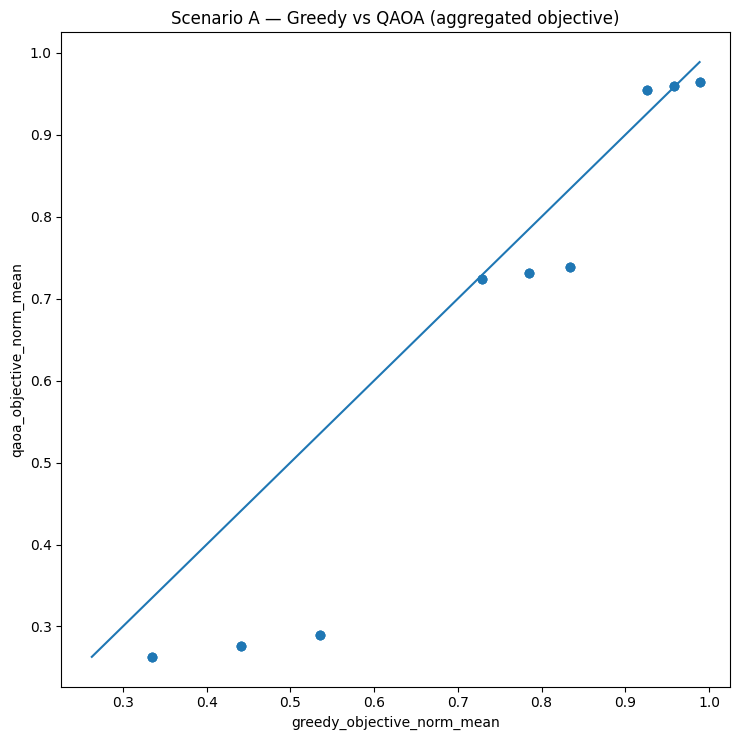

Saved: outputs/figures/05c_compare_objective_scatter.png


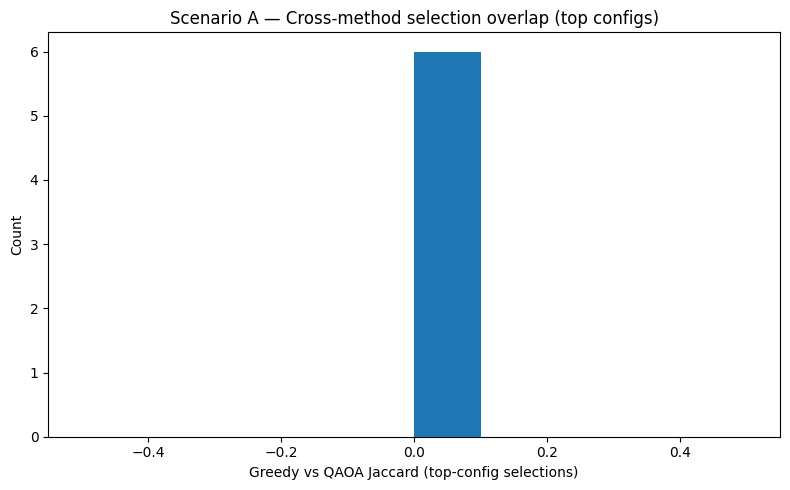

Saved: outputs/figures/05c_compare_topconfig_overlap_jaccard.png


In [5]:
# ============================================================
# Cell 5 — Figures: objective scatter + overlap distribution
# ============================================================

# --- Figure 1: Objective comparison scatter (aggregated mean objective_norm if present) ---
x_col = "greedy_objective_norm_mean" if "greedy_objective_norm_mean" in compare.columns else "greedy_objective_mean"
y_col = "qaoa_objective_norm_mean" if "qaoa_objective_norm_mean" in compare.columns else "qaoa_objective_mean"

plt.figure(figsize=(7.5, 7.5))
plt.scatter(compare[x_col], compare[y_col])

# 45-degree reference line
xmin = float(min(compare[x_col].min(), compare[y_col].min()))
xmax = float(max(compare[x_col].max(), compare[y_col].max()))
plt.plot([xmin, xmax], [xmin, xmax])

plt.xlabel(f"{x_col}")
plt.ylabel(f"{y_col}")
plt.title("Scenario A — Greedy vs QAOA (aggregated objective)")
plt.tight_layout()
plt.savefig(PATH_FIG_SCATTER, dpi=160)
plt.show()
print("Saved:", PATH_FIG_SCATTER)

# --- Figure 2: Overlap (Jaccard) distribution for matched top-config keys ---
plt.figure(figsize=(8, 5))
plt.hist(overlap_df["greedy_vs_qaoa_jaccard"], bins=10)
plt.xlabel("Greedy vs QAOA Jaccard (top-config selections)")
plt.ylabel("Count")
plt.title("Scenario A — Cross-method selection overlap (top configs)")
plt.tight_layout()
plt.savefig(PATH_FIG_OVERLAP, dpi=160)
plt.show()
print("Saved:", PATH_FIG_OVERLAP)

### What Cell 5 Just Did

- Created and saved a scatter plot comparing greedy vs QAOA aggregated objective (normalized if available).
- Created and saved a histogram of cross-method selection overlap (Jaccard) across matched “top config” exports.
- These two figures are meant to be quick slide-ready summaries: “Does QAOA beat greedy?” and “Do they pick the same trials?”


In [6]:
# ============================================================
# Cell 6 — Wrap-up: top deltas and artifact summary (join-mode safe)
# ============================================================

print("Top configs where QAOA improves most (by normalized objective if available):")

# Build a safe column list that only includes columns that exist
base_key_cols = ["lambda_cost", "lambda_safety", "noise_sigma"]
if "K" in compare.columns:
    base_key_cols = ["K"] + base_key_cols

cols_show = base_key_cols.copy()

candidate_metric_cols = [
    "greedy_objective_mean", "qaoa_objective_mean", "delta_objective_mean",
    "greedy_objective_norm_mean", "qaoa_objective_norm_mean", "delta_objective_norm_mean",
    "greedy_jaccard_vs_baseline_mean", "qaoa_jaccard_vs_baseline_mean", "delta_jaccard_vs_baseline_mean",
    "greedy_selected_n_mean", "qaoa_selected_n_mean", "delta_selected_n_mean",
    "_join_mode"
]

for c in candidate_metric_cols:
    if c in compare.columns:
        cols_show.append(c)

display(compare[cols_show].head(15))

print("\nTop cross-method overlaps (selections):")
display(overlap_df.head(15))

print("\nArtifacts written:")
print("  -", PATH_COMPARE_CONFIG_METRICS)
print("  -", PATH_COMPARE_TOP_OVERLAP)
print("  -", PATH_FIG_SCATTER)
print("  -", PATH_FIG_OVERLAP)

print("\nDone.")


Top configs where QAOA improves most (by normalized objective if available):


,lambda_cost,lambda_safety,noise_sigma,greedy_objective_mean,qaoa_objective_mean,delta_objective_mean,greedy_objective_norm_mean,qaoa_objective_norm_mean,delta_objective_norm_mean,greedy_jaccard_vs_baseline_mean,qaoa_jaccard_vs_baseline_mean,delta_jaccard_vs_baseline_mean,greedy_selected_n_mean,qaoa_selected_n_mean,delta_selected_n_mean,_join_mode
0,0.5,0.5,0.00,-20.000000,-3.600000,16.400000,0.926305,0.954615,0.028310,0.722222,0.623737,-0.098485,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
1,0.5,1.0,0.00,-20.000000,-3.600000,16.400000,0.926305,0.954615,0.028310,0.722222,0.623737,-0.098485,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
2,0.5,2.0,0.00,-20.000000,-3.600000,16.400000,0.926305,0.954615,0.028310,0.722222,0.623737,-0.098485,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
3,0.5,0.5,0.05,-11.941932,-3.421907,8.520025,0.958068,0.959177,0.001109,0.003323,0.568182,0.564859,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
4,0.5,1.0,0.05,-11.941932,-3.421907,8.520025,0.958068,0.959177,0.001109,0.003323,0.568182,0.564859,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
5,0.5,2.0,0.05,-11.941932,-3.421907,8.520025,0.958068,0.959177,0.001109,0.003323,0.568182,0.564859,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
6,1.0,0.5,0.00,-70.000000,-12.600000,57.400000,0.729219,0.724064,-0.005156,0.722222,0.638889,-0.083333,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
7,1.0,2.0,0.00,-70.000000,-12.600000,57.400000,0.729219,0.724064,-0.005156,0.722222,0.638889,-0.083333,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
8,1.0,1.0,0.00,-70.000000,-12.600000,57.400000,0.729219,0.724064,-0.005156,0.722222,0.638889,-0.083333,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized
9,0.5,0.5,0.10,-4.176407,-3.242679,0.933728,0.988678,0.963769,-0.024909,0.002650,0.553030,0.550381,50.0,9.0,-41.0,loose_on_lambdas_noise__K_marginalized



Top cross-method overlaps (selections):


,lambda_cost,lambda_safety,noise_sigma,seed,greedy_n,qaoa_n,intersection_n,union_n,greedy_vs_qaoa_jaccard
0,0.5,0.5,0.05,0,25,6,0,31,0.0
1,0.5,0.5,0.10,0,75,9,0,84,0.0
2,0.5,1.0,0.05,0,25,6,0,31,0.0
3,0.5,1.0,0.10,0,50,6,0,56,0.0
4,0.5,2.0,0.05,0,25,6,0,31,0.0
5,0.5,2.0,0.10,0,50,6,0,56,0.0



Artifacts written:
  - data/results/05c_compare_config_metrics.csv
  - data/results/05c_compare_topconfig_selection_overlap.csv
  - outputs/figures/05c_compare_objective_scatter.png
  - outputs/figures/05c_compare_topconfig_overlap_jaccard.png

Done.


### What Cell 6 Just Did

- Displayed the strongest QAOA-vs-greedy improvements (by delta objective) for the comparison join that was actually used:
  - strict join includes `K`
  - loose join marginalizes over `K` and omits it
- Displayed the highest cross-method overlaps from Cell 4.
- Printed the 05c output artifact paths so you can quickly find the CSVs and figures.


## Summary

This notebook produces an apples-to-apples comparison of 05a vs 05b for Scenario A by:

- Jointly aggregating sweep results across seeds for matched `(K, lambda_cost, lambda_safety, noise_sigma)` keys
- Reporting deltas (QAOA − Greedy) for objective and stability metrics (where defined)
- Computing **cross-method selection overlap** (Jaccard) from the exported “top configs selected trials”
- Writing comparison tables and two slide-friendly figures

Next natural upgrade (optional):
- Add a “matched-config heatmap” of `delta_objective_norm_mean` for a fixed K and noise slice.
- Add a “Pareto” view: objective improvement vs overlap (Jaccard) to visualize when QAOA changes selections substantially.
